# 03 Model Preparation and Baseline Regression

This notebook develops the first formal modeling stage for the building energy efficiency project. The aim is to establish statistically interpretable baseline models for predicting:

- **Heating Load**
- **Cooling Load**

The notebook focuses on model preparation, baseline ordinary least squares regression, regression diagnostics, multicollinearity assessment, and regularized regression models.

## Modeling Rationale

The EDA showed that the data are clean and complete, but the predictor structure contains strong geometric relationships and severe multicollinearity. Therefore, the first modeling stage should not immediately jump to complex machine learning models. Instead, we begin with interpretable regression models to understand baseline predictive performance and statistical limitations.

This notebook therefore considers:

1. **Ordinary Least Squares Regression** as the baseline parametric model.
2. **Ridge Regression** to handle multicollinearity through L2 regularization.
3. **LASSO Regression** to assess whether sparse feature selection is useful.
4. **Elastic Net Regression** to combine Ridge and LASSO behavior.

In [16]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, ElasticNetCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from scipy import stats

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

In [2]:
# ============================================================
# 2. LOAD CLEAN DATA
# ============================================================

DATA_PATH = Path("data/clean/clean_df.csv")

if not DATA_PATH.exists():
    # Fallback if notebook is inside a notebooks/ directory
    DATA_PATH = Path("../data/clean/clean_df.csv")

assert DATA_PATH.exists(), f"Clean data file not found: {DATA_PATH}"

df = pd.read_csv(DATA_PATH)

print("Data loaded from:", DATA_PATH)
print("Shape:", df.shape)
display(df.head())

Data loaded from: data\clean\clean_df.csv
Shape: (768, 11)


,relative_compactness,surface_area,wall_area,roof_area,overall_height,orientation,glazing_area,glazing_area_distribution,heating_load,cooling_load,any_outlier_flag
0,0.9800,514.5000,294.0000,110.2500,7.0000,2,0.0000,0,15.5500,21.3300,False
1,0.9800,514.5000,294.0000,110.2500,7.0000,3,0.0000,0,15.5500,21.3300,False
2,0.9800,514.5000,294.0000,110.2500,7.0000,4,0.0000,0,15.5500,21.3300,False
3,0.9800,514.5000,294.0000,110.2500,7.0000,5,0.0000,0,15.5500,21.3300,False
4,0.9000,563.5000,318.5000,122.5000,7.0000,2,0.0000,0,20.8400,28.2800,False


In [3]:
# ============================================================
# 3. VARIABLE DEFINITIONS
# ============================================================

feature_cols = [
    "relative_compactness",
    "surface_area",
    "wall_area",
    "roof_area",
    "overall_height",
    "orientation",
    "glazing_area",
    "glazing_area_distribution",
]

target_cols = ["heating_load", "cooling_load"]

categorical_features = ["orientation", "glazing_area_distribution"]
continuous_features = [
    "relative_compactness",
    "surface_area",
    "wall_area",
    "roof_area",
    "overall_height",
    "glazing_area",
]

# Ensure semantic categorical handling after CSV reload
for col in categorical_features:
    df[col] = df[col].astype("category")

print(df[feature_cols + target_cols].dtypes)

relative_compactness          float64
surface_area                  float64
wall_area                     float64
roof_area                     float64
overall_height                float64
orientation                  category
glazing_area                  float64
glazing_area_distribution    category
heating_load                  float64
cooling_load                  float64
dtype: object


> **Note:** `orientation` and `glazing_area_distribution` are stored as numeric codes in the raw data, but they represent categorical design settings rather than continuous measurements. They are therefore treated as categorical variables during modeling.

In [4]:
# ============================================================
# 4. BASIC MODELING READINESS CHECK
# ============================================================

readiness_report = pd.DataFrame({
    "dtype": df[feature_cols + target_cols].dtypes,
    "non_null_count": df[feature_cols + target_cols].count(),
    "missing_count": df[feature_cols + target_cols].isna().sum(),
    "missing_percent": df[feature_cols + target_cols].isna().mean() * 100,
    "unique_count": df[feature_cols + target_cols].nunique(),
})

display(readiness_report)

,dtype,non_null_count,missing_count,missing_percent,unique_count
relative_compactness,float64,768,0,0.0000,12
surface_area,float64,768,0,0.0000,12
wall_area,float64,768,0,0.0000,7
roof_area,float64,768,0,0.0000,4
overall_height,float64,768,0,0.0000,2
orientation,category,768,0,0.0000,4
glazing_area,float64,768,0,0.0000,4
glazing_area_distribution,category,768,0,0.0000,6
heating_load,float64,768,0,0.0000,587
cooling_load,float64,768,0,0.0000,636


In [5]:
# ============================================================
# 5. TRAIN-TEST SPLIT
# ============================================================

X = df[feature_cols].copy()
y_heating = df["heating_load"].copy()
y_cooling = df["cooling_load"].copy()

X_train, X_test, y_heat_train, y_heat_test, y_cool_train, y_cool_test = train_test_split(
    X,
    y_heating,
    y_cooling,
    test_size=0.20,
    random_state=42,
)

print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)
print("Heating train/test:", y_heat_train.shape, y_heat_test.shape)
print("Cooling train/test:", y_cool_train.shape, y_cool_test.shape)

Training feature shape: (614, 8)
Testing feature shape: (154, 8)
Heating train/test: (614,) (154,)
Cooling train/test: (614,) (154,)


In [6]:
# ============================================================
# 6. PREPROCESSING PIPELINE
# ============================================================

preprocessor = ColumnTransformer(
    transformers=[
        ("continuous", StandardScaler(), continuous_features),
        ("categorical", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features),
    ],
    remainder="drop",
)

# Get transformed feature names for interpretation later
preprocessor.fit(X_train)

encoded_cat_names = list(
    preprocessor.named_transformers_["categorical"]
    .get_feature_names_out(categorical_features)
)

model_feature_names = continuous_features + encoded_cat_names

print("Number of model features after encoding:", len(model_feature_names))
print(model_feature_names)

Number of model features after encoding: 14
['relative_compactness', 'surface_area', 'wall_area', 'roof_area', 'overall_height', 'glazing_area', 'orientation_3', 'orientation_4', 'orientation_5', 'glazing_area_distribution_1', 'glazing_area_distribution_2', 'glazing_area_distribution_3', 'glazing_area_distribution_4', 'glazing_area_distribution_5']


In [7]:
# ============================================================
# 7. HELPER FUNCTIONS
# ============================================================

def regression_metrics(y_true, y_pred):
    '''Return common regression performance metrics.'''
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return {
        "R2": r2,
        "RMSE": rmse,
        "MAE": mae,
        "MAPE_percent": mape,
    }


def adjusted_r2(r2, n, p):
    '''Calculate adjusted R-squared.'''
    return 1 - ((1 - r2) * (n - 1) / (n - p - 1))


def evaluate_model(model, X_train, X_test, y_train, y_test, target_name, model_name):
    '''Fit model and return train/test metrics.'''
    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_metrics = regression_metrics(y_train, train_pred)
    test_metrics = regression_metrics(y_test, test_pred)

    p = len(model_feature_names)
    train_metrics["Adjusted_R2"] = adjusted_r2(train_metrics["R2"], len(y_train), p)
    test_metrics["Adjusted_R2"] = adjusted_r2(test_metrics["R2"], len(y_test), p)

    rows = []
    for split, metrics in [("Train", train_metrics), ("Test", test_metrics)]:
        row = {
            "Target": target_name,
            "Model": model_name,
            "Split": split,
        }
        row.update(metrics)
        rows.append(row)

    return pd.DataFrame(rows), train_pred, test_pred

## 8. Baseline Ordinary Least Squares Regression

Ordinary Least Squares Regression is used as the baseline because it provides a simple, interpretable parametric benchmark. However, based on the EDA, we expect coefficient interpretation to be affected by multicollinearity among the geometric predictors.

In [12]:
# ============================================================
# 8. BASELINE LINEAR REGRESSION MODELS
# ============================================================

ols_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression()),
    ]
)

heat_ols_results, heat_ols_train_pred, heat_ols_test_pred = evaluate_model(
    ols_pipeline,
    X_train,
    X_test,
    y_heat_train,
    y_heat_test,
    target_name="Heating Load",
    model_name="OLS Linear Regression",
)

cool_ols_results, cool_ols_train_pred, cool_ols_test_pred = evaluate_model(
    ols_pipeline,
    X_train,
    X_test,
    y_cool_train,
    y_cool_test,
    target_name="Cooling Load",
    model_name="OLS Linear Regression",
)

# ============================================================
# STORE FITTED OLS MODELS FOR DIAGNOSTICS
# ============================================================

heating_load_ols_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression()),
    ]
).fit(X_train, y_heat_train)

cooling_load_ols_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression()),
    ]
).fit(X_train, y_cool_train)

baseline_results = pd.concat(
    [heat_ols_results, cool_ols_results],
    ignore_index=True
)

display(baseline_results)

,Target,Model,Split,R2,RMSE,MAE,MAPE_percent,Adjusted_R2
0,Heating Load,OLS Linear Regression,Train,0.9242,2.7667,1.9880,9.4538,0.9224
1,Heating Load,OLS Linear Regression,Test,0.9209,2.8723,2.0590,9.5062,0.9129
2,Cooling Load,OLS Linear Regression,Train,0.8883,3.1652,2.2600,9.0050,0.8856
3,Cooling Load,OLS Linear Regression,Test,0.8950,3.1198,2.1805,8.4159,0.8844


### Baseline Linear Regression Performance

The baseline Ordinary Least Squares (OLS) regression model demonstrated strong predictive performance for both Heating Load and Cooling Load. For Heating Load, the model achieved a test \(R^2\) of 0.9209, indicating that approximately 92.1% of the variation in heating demand can be explained by the building characteristics. Similarly, the Cooling Load model achieved a test \(R^2\) of 0.8950, explaining nearly 89.5% of the variation in cooling demand. The small differences between training and testing metrics suggest that the models generalize well and show little evidence of overfitting. Overall, these results indicate that the predictor variables contain substantial information about building energy requirements, although further improvements may be possible through regularized, semi-parametric, or non-linear modeling approaches.

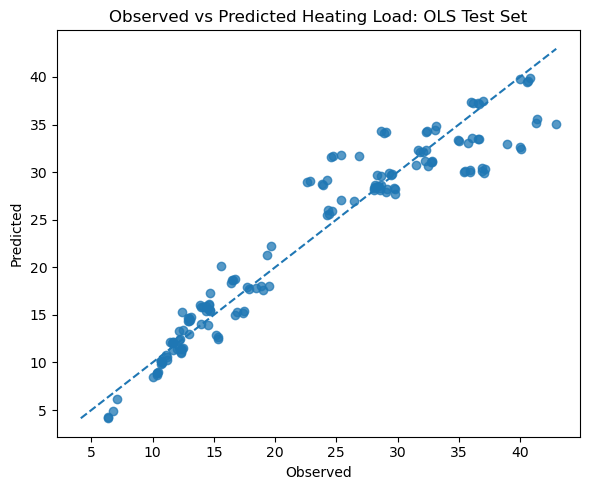

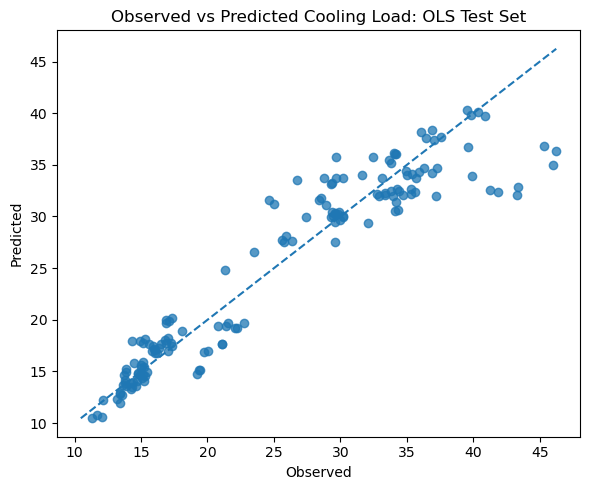

In [13]:
# ============================================================
# 9. OBSERVED VS PREDICTED PLOTS
# ============================================================

def plot_observed_vs_predicted(y_true, y_pred, title):
    plt.figure(figsize=(6, 5))
    plt.scatter(y_true, y_pred, alpha=0.75)
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
    plt.title(title)
    plt.xlabel("Observed")
    plt.ylabel("Predicted")
    plt.tight_layout()
    plt.show()

plot_observed_vs_predicted(
    y_heat_test,
    heat_ols_test_pred,
    "Observed vs Predicted Heating Load: OLS Test Set",
)

plot_observed_vs_predicted(
    y_cool_test,
    cool_ols_test_pred,
    "Observed vs Predicted Cooling Load: OLS Test Set",
)

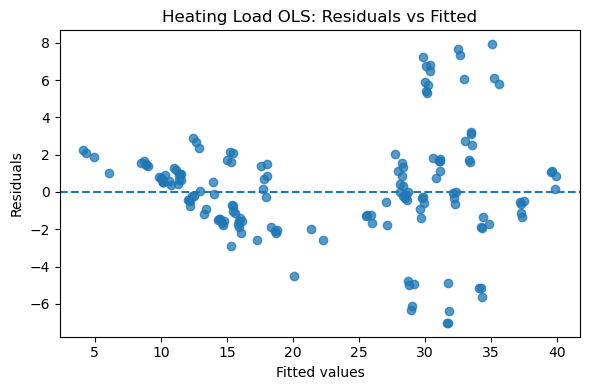

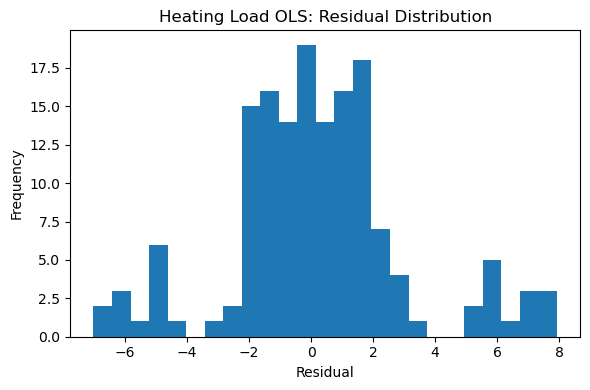

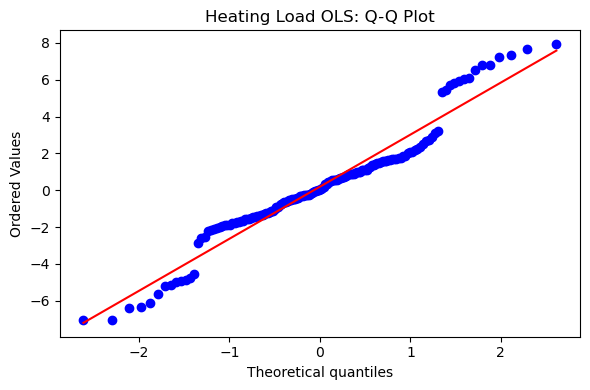

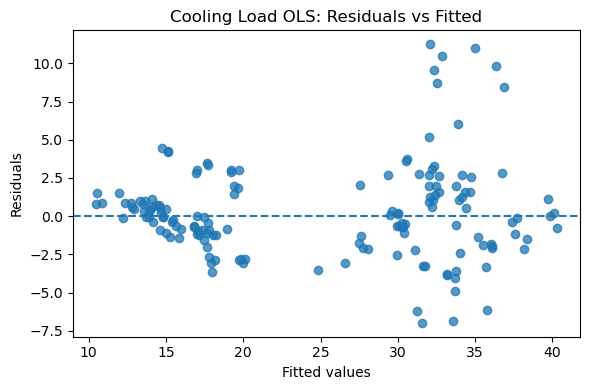

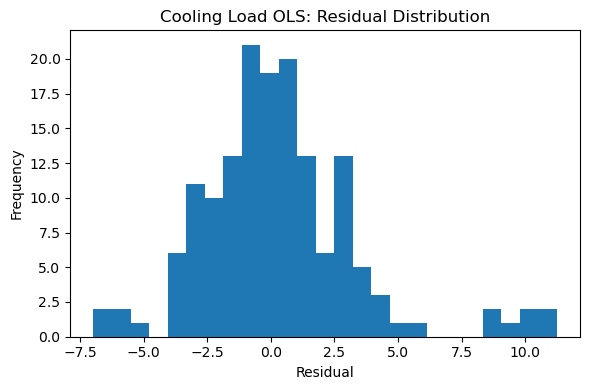

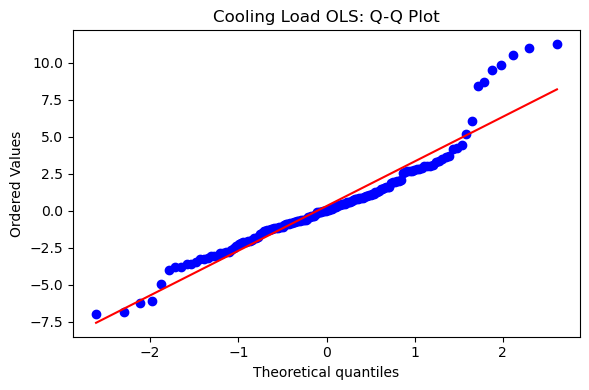

In [11]:
# ============================================================
# 10. RESIDUAL DIAGNOSTIC PLOTS
# ============================================================

def residual_diagnostics(y_true, y_pred, title_prefix):
    residuals = y_true - y_pred

    plt.figure(figsize=(6, 4))
    plt.scatter(y_pred, residuals, alpha=0.75)
    plt.axhline(0, linestyle="--")
    plt.title(f"{title_prefix}: Residuals vs Fitted")
    plt.xlabel("Fitted values")
    plt.ylabel("Residuals")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.hist(residuals, bins=25)
    plt.title(f"{title_prefix}: Residual Distribution")
    plt.xlabel("Residual")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

    fig = plt.figure(figsize=(6, 4))
    stats.probplot(residuals, dist="norm", plot=plt)
    plt.title(f"{title_prefix}: Q-Q Plot")
    plt.tight_layout()
    plt.show()

residual_diagnostics(y_heat_test, heat_ols_test_pred, "Heating Load OLS")
residual_diagnostics(y_cool_test, cool_ols_test_pred, "Cooling Load OLS")


# OLS Assumption Diagnostics

The validity of Ordinary Least Squares (OLS) regression depends on several statistical assumptions. Although the baseline models achieved strong predictive performance, it is important to verify whether the underlying assumptions required for reliable inference and interpretation are satisfied.

The following diagnostics are conducted separately for the Heating Load and Cooling Load models:

1. Linearity
2. Normality of Residuals
3. Homoscedasticity (Constant Error Variance)
4. Independence of Errors
5. Multicollinearity
6. Influential Observations and Leverage Points
7. Model Specification

Both visual diagnostics and formal statistical tests are used wherever applicable.

In [14]:
# ============================================================
# HEATING LOAD MODEL RESIDUALS
# ============================================================

heat_train_pred = heating_load_ols_model.predict(X_train)

heat_residuals = y_heat_train - heat_train_pred

print("Residual vector shape:", heat_residuals.shape)

Residual vector shape: (614,)


>> ### Assumption 1: Linearity
- Residuals should be randomly scattered around zero with no systematic structure.

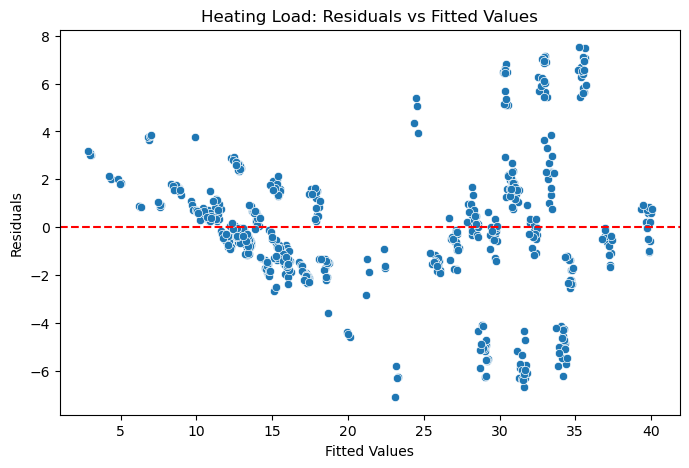

In [17]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=heat_train_pred,
    y=heat_residuals
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Heating Load: Residuals vs Fitted Values")

plt.show()

>> ### Assumption 2: Normality of Residuals

OLS assumes that residuals follow an approximately normal distribution. This assumption is assessed using both graphical and statistical methods.

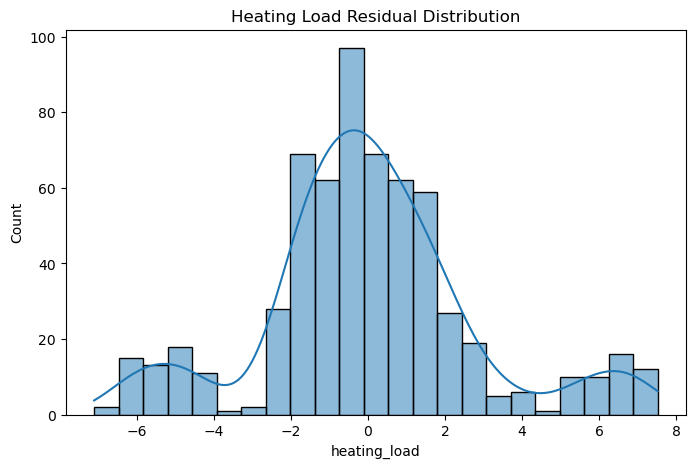

In [18]:
plt.figure(figsize=(8,5))

sns.histplot(
    heat_residuals,
    kde=True
)

plt.title("Heating Load Residual Distribution")

plt.show()

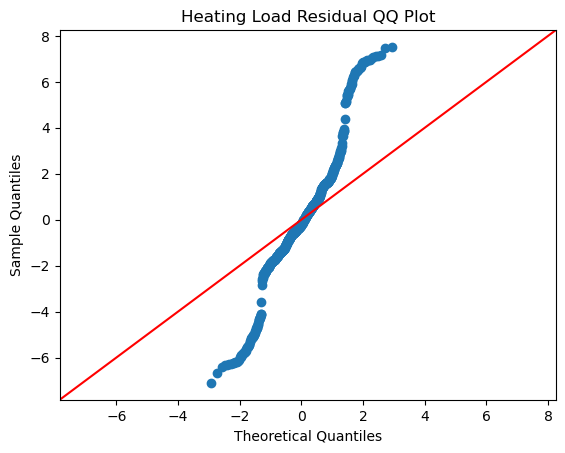

In [19]:
import statsmodels.api as sm

sm.qqplot(
    heat_residuals,
    line="45"
)

plt.title("Heating Load Residual QQ Plot")

plt.show()

>> ### Assumption 3: Homoscedasticity

OLS assumes constant variance of residuals across fitted values. This assumption is evaluated visually and through the Breusch-Pagan test.

In [25]:
# ============================================================
# BREUSCH-PAGAN TEST: HEATING LOAD MODEL
# ============================================================

import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan

X_heat_sm = pd.get_dummies(
    X_train,
    drop_first=True
).astype(float)

X_heat_sm = sm.add_constant(X_heat_sm)

y_heat_train_sm = y_heat_train.astype(float)

heat_sm_model = sm.OLS(
    y_heat_train_sm,
    X_heat_sm
).fit()

bp = het_breuschpagan(
    heat_sm_model.resid,
    heat_sm_model.model.exog
)

bp_results = pd.DataFrame({
    "Test": ["Breusch-Pagan"],
    "LM Statistic": [bp[0]],
    "LM P-value": [bp[1]],
    "F Statistic": [bp[2]],
    "F P-value": [bp[3]]
})

display(bp_results)

,Test,LM Statistic,LM P-value,F Statistic,F P-value
0,Breusch-Pagan,296.9598,0.0000,43.2306,0.0000


> **Note:** A separate `statsmodels` OLS object was fitted solely for formal diagnostic testing. While the primary prediction model was trained using `sklearn`, statistical diagnostics such as the Breusch-Pagan test require direct access to model residuals and the design matrix provided by `statsmodels`. The Breusch-Pagan test produced an LM statistic of **296.96** and an F statistic of **43.23**, with both p-values less than **0.001**. These results provide strong evidence against the null hypothesis of constant error variance, indicating that the Heating Load OLS model exhibits **heteroscedasticity**, and therefore the homoscedasticity assumption is violated.

>> ### Assumption 4: Independence of Errors

Residuals should be independent. The Durbin-Watson statistic is used to assess autocorrelation.

In [26]:
from statsmodels.stats.stattools import durbin_watson

dw = durbin_watson(
    heat_sm_model.resid
)

print("Durbin-Watson:", round(dw,4))

Durbin-Watson: 1.8903


> The Durbin-Watson statistic for the Heating Load OLS model was **1.8903**, which is very close to the ideal value of **2.0**. This indicates that there is little evidence of autocorrelation in the residuals, suggesting that the independence of errors assumption is reasonably satisfied.

>> ### Assumption 5: Multicollinearity

Multicollinearity occurs when predictors contain redundant information. Variance Inflation Factors (VIFs) are used to assess predictor redundancy.

In [28]:
# ============================================================
# VARIANCE INFLATION FACTOR (VIF)
# ============================================================

from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = pd.get_dummies(
    X_train,
    drop_first=True
).astype(float)

vif_table = pd.DataFrame({
    "Variable": X_vif.columns,
    "VIF": [
        variance_inflation_factor(
            X_vif.values,
            i
        )
        for i in range(X_vif.shape[1])
    ]
})

vif_table = vif_table.sort_values(
    by="VIF",
    ascending=False
)

display(vif_table)

,Variable,VIF
1,surface_area,inf
2,wall_area,inf
3,roof_area,inf
0,relative_compactness,173.5272
4,overall_height,134.2070
5,glazing_area,5.2352
11,glazing_area_distribution_3,4.8345
9,glazing_area_distribution_1,4.7662
10,glazing_area_distribution_2,4.6883
13,glazing_area_distribution_5,4.6851


> The VIF analysis reveals severe multicollinearity among several geometric building characteristics. Surface Area, Wall Area, and Roof Area exhibit infinite VIF values, while Relative Compactness (VIF = 173.53) and Overall Height (VIF = 134.21) also show extremely high multicollinearity, indicating substantial redundancy among predictors. These results confirm the multicollinearity concerns identified during EDA and suggest that coefficient estimates from the OLS model may be unstable, motivating the use of regularized regression techniques such as Ridge and LASSO.

>> ### Assumption 6: Influential Observations

Cook's Distance is used to identify observations that may disproportionately influence the fitted model.

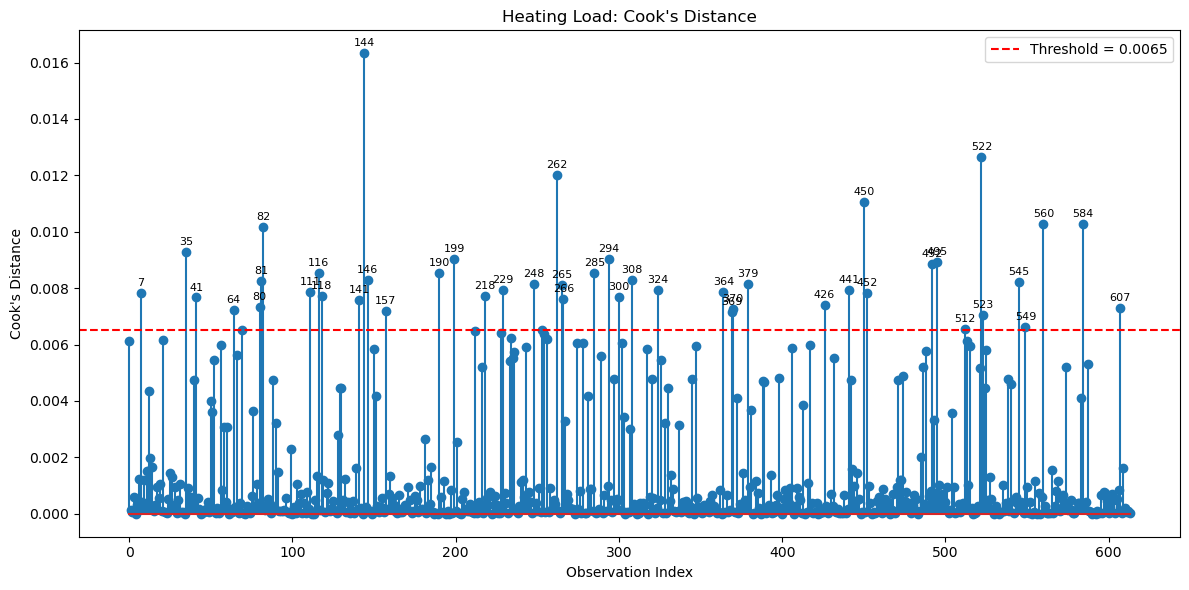

In [31]:
# ============================================================
# COOK'S DISTANCE
# ============================================================

influence = heat_sm_model.get_influence()

cooks_d = influence.cooks_distance[0]

threshold = 4 / len(cooks_d)

plt.figure(figsize=(12,6))

markerline, stemlines, baseline = plt.stem(
    range(len(cooks_d)),
    cooks_d
)

plt.axhline(
    threshold,
    color="red",
    linestyle="--",
    label=f"Threshold = {threshold:.4f}"
)

# Label influential observations
for i, value in enumerate(cooks_d):
    if value > threshold:
        plt.annotate(
            str(i),
            xy=(i, value),
            xytext=(0, 5),
            textcoords="offset points",
            ha="center",
            fontsize=8
        )

plt.xlabel("Observation Index")
plt.ylabel("Cook's Distance")
plt.title("Heating Load: Cook's Distance")
plt.legend()

plt.tight_layout()
plt.show()

>> ### Assumption 7: Model Specification

The Ramsey RESET test is used to assess whether important nonlinear terms may be missing from the model.

In [30]:
from statsmodels.stats.diagnostic import linear_reset

reset = linear_reset(
    heat_sm_model,
    power=2,
    use_f=True
)

print("RESET p-value:", reset.pvalue)

RESET p-value: 3.8275529072769626e-17


> The Ramsey RESET test produced a p-value of **3.83 × 10⁻¹⁷**, which is far below the conventional significance level of 0.05. This result suggests that the Heating Load OLS model may suffer from model misspecification, indicating that important nonlinear relationships or interaction effects are not fully captured by the current linear formulation. Consequently, the model specification assumption is violated, providing further justification for exploring more flexible approaches such as Generalized Additive Models (GAMs) and other nonlinear machine learning models.

# Assumption Diagnostics: Cooling Load OLS Regression Model

The assumptions of the Cooling Load OLS regression model are evaluated using the same diagnostic procedures applied to the Heating Load model. Both visual and statistical diagnostics are examined to assess whether the assumptions required for valid Ordinary Least Squares inference are satisfied.

In [32]:
# ============================================================
# COOLING LOAD MODEL RESIDUALS
# ============================================================

cool_train_pred = cooling_load_ols_model.predict(X_train)

cool_residuals = y_cool_train - cool_train_pred

print("Residual vector shape:", cool_residuals.shape)

Residual vector shape: (614,)


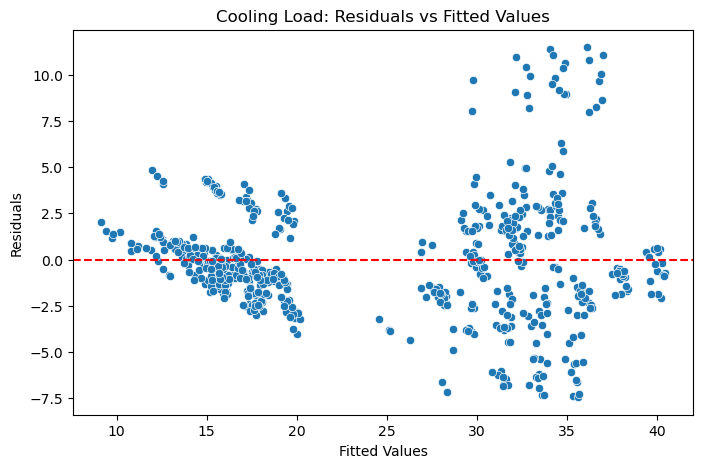

In [33]:
# ============================================================
# LINEARITY CHECK: RESIDUALS VS FITTED VALUES
# ============================================================

plt.figure(figsize=(8,5))

sns.scatterplot(
    x=cool_train_pred,
    y=cool_residuals
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Cooling Load: Residuals vs Fitted Values")

plt.show()

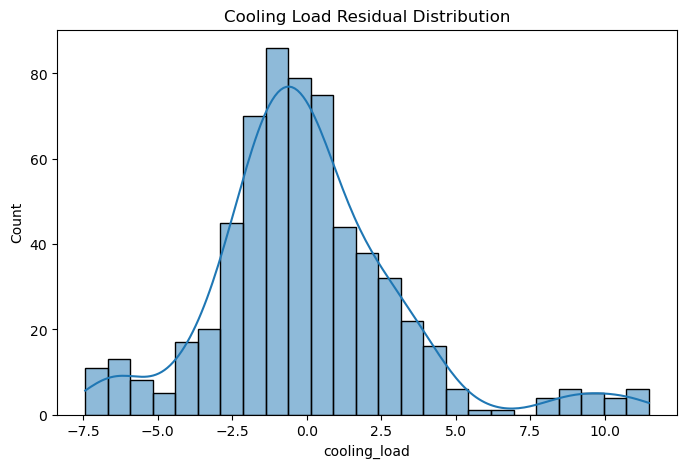

In [34]:
# ============================================================
# NORMALITY CHECK: RESIDUAL DISTRIBUTION
# ============================================================

plt.figure(figsize=(8,5))

sns.histplot(
    cool_residuals,
    kde=True
)

plt.title("Cooling Load Residual Distribution")

plt.show()

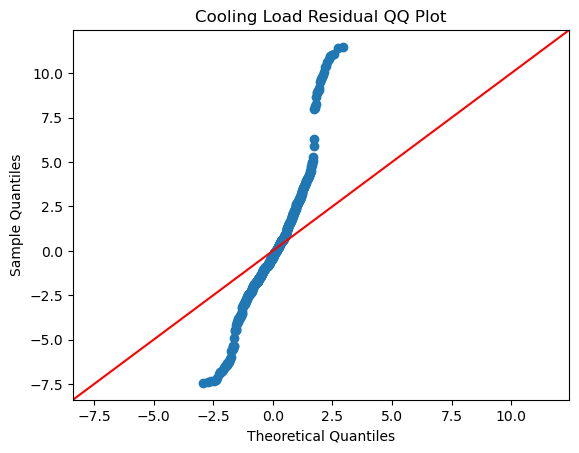

In [35]:
# ============================================================
# NORMALITY CHECK: QQ PLOT
# ============================================================

import statsmodels.api as sm

sm.qqplot(
    cool_residuals,
    line="45"
)

plt.title("Cooling Load Residual QQ Plot")

plt.show()

In [36]:
# ============================================================
# BREUSCH-PAGAN TEST: COOLING LOAD MODEL
# ============================================================

import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan

X_cool_sm = pd.get_dummies(
    X_train,
    drop_first=True
).astype(float)

X_cool_sm = sm.add_constant(X_cool_sm)

y_cool_train_sm = y_cool_train.astype(float)

cool_sm_model = sm.OLS(
    y_cool_train_sm,
    X_cool_sm
).fit()

bp = het_breuschpagan(
    cool_sm_model.resid,
    cool_sm_model.model.exog
)

bp_results = pd.DataFrame({
    "Test": ["Breusch-Pagan"],
    "LM Statistic": [bp[0]],
    "LM P-value": [bp[1]],
    "F Statistic": [bp[2]],
    "F P-value": [bp[3]]
})

display(bp_results)

,Test,LM Statistic,LM P-value,F Statistic,F P-value
0,Breusch-Pagan,175.7707,0.0000,18.5120,0.0000


> The Breusch-Pagan test produced an LM statistic of **175.77** and an F statistic of **18.51**, with both p-values less than **0.001**. These results provide strong evidence against the null hypothesis of constant error variance, indicating that the residual variance changes across fitted values. Therefore, the Cooling Load OLS model exhibits **heteroscedasticity**, suggesting that the homoscedasticity assumption is violated.

In [37]:
# ============================================================
# DURBIN-WATSON TEST: COOLING LOAD MODEL
# ============================================================

from statsmodels.stats.stattools import durbin_watson

dw = durbin_watson(
    cool_sm_model.resid
)

print("Durbin-Watson:", round(dw,4))

Durbin-Watson: 1.9406


> The Durbin-Watson statistic for the Cooling Load OLS model was **1.9406**, which is very close to the ideal value of **2.0**. This indicates little evidence of autocorrelation among the residuals, suggesting that the independence of errors assumption is reasonably satisfied.

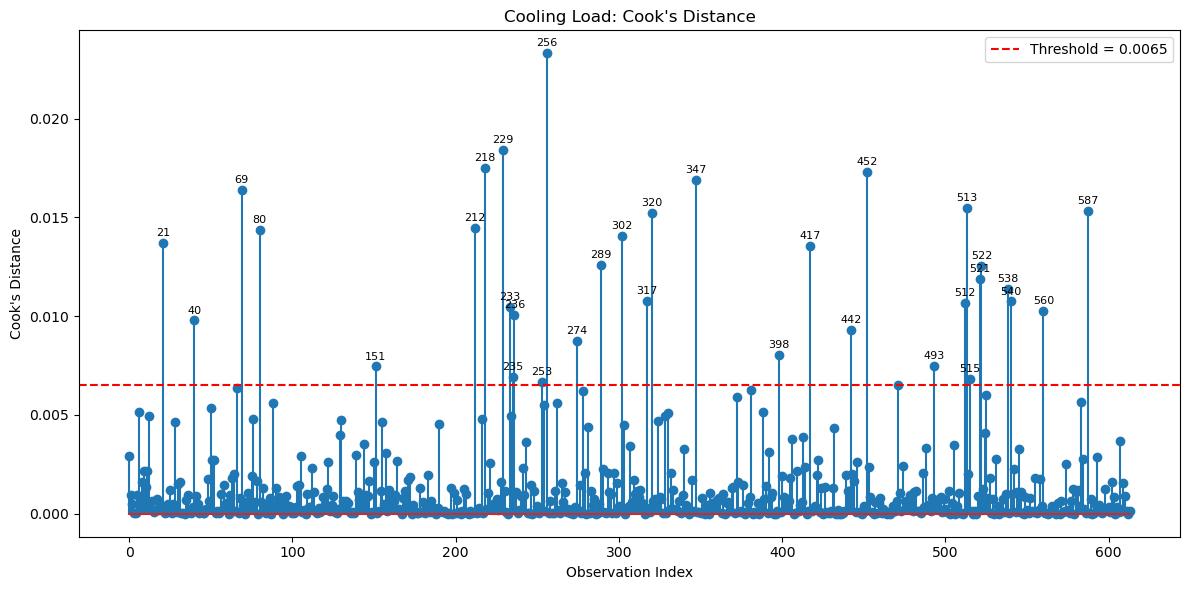

In [38]:
# ============================================================
# COOK'S DISTANCE: COOLING LOAD MODEL
# ============================================================

influence = cool_sm_model.get_influence()

cooks_d = influence.cooks_distance[0]

threshold = 4 / len(cooks_d)

plt.figure(figsize=(12,6))

markerline, stemlines, baseline = plt.stem(
    range(len(cooks_d)),
    cooks_d
)

plt.axhline(
    threshold,
    color="red",
    linestyle="--",
    label=f"Threshold = {threshold:.4f}"
)

for i, value in enumerate(cooks_d):
    if value > threshold:
        plt.annotate(
            str(i),
            xy=(i, value),
            xytext=(0, 5),
            textcoords="offset points",
            ha="center",
            fontsize=8
        )

plt.xlabel("Observation Index")
plt.ylabel("Cook's Distance")
plt.title("Cooling Load: Cook's Distance")
plt.legend()

plt.tight_layout()
plt.show()

In [39]:
# ============================================================
# RAMSEY RESET TEST: COOLING LOAD MODEL
# ============================================================

from statsmodels.stats.diagnostic import linear_reset

reset = linear_reset(
    cool_sm_model,
    power=2,
    use_f=True
)

print("RESET p-value:", reset.pvalue)

RESET p-value: 5.9981349512136095e-06


> The Ramsey RESET test produced a p-value of **5.998 × 10⁻⁶**, which is substantially smaller than the significance level of 0.05. This result provides strong evidence that the Cooling Load OLS model may be misspecified, suggesting the presence of important nonlinear relationships or interaction effects that are not adequately captured by the current linear model. Consequently, the model specification assumption is violated, supporting the consideration of more flexible modeling approaches such as Generalized Additive Models (GAMs) and other nonlinear machine learning techniques.

In [40]:
# ============================================================
# SAVE MODELING DATASET
# ============================================================

from pathlib import Path

OUTPUT_DIR = Path("../data/modeling")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

modeling_df = df.copy()

modeling_df.to_csv(
    OUTPUT_DIR / "modeling_df.csv",
    index=False
)

print("Modeling dataset saved successfully to:", OUTPUT_DIR / "modeling_df.csv")

Modeling dataset saved successfully to: ..\data\modeling\modeling_df.csv


In [43]:
# ============================================================
# SAVE TRAINING AND TESTING DATASETS
# ============================================================

from pathlib import Path

OUTPUT_DIR = Path("../data/modeling")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Features
X_train.to_csv(
    OUTPUT_DIR / "X_train.csv",
    index=False
)

X_test.to_csv(
    OUTPUT_DIR / "X_test.csv",
    index=False
)

# Heating Load
y_heat_train.to_frame(name="heating_load").to_csv(
    OUTPUT_DIR / "y_heat_train.csv",
    index=False
)

y_heat_test.to_frame(name="heating_load").to_csv(
    OUTPUT_DIR / "y_heat_test.csv",
    index=False
)

# Cooling Load
y_cool_train.to_frame(name="cooling_load").to_csv(
    OUTPUT_DIR / "y_cool_train.csv",
    index=False
)

y_cool_test.to_frame(name="cooling_load").to_csv(
    OUTPUT_DIR / "y_cool_test.csv",
    index=False
)

print("Files saved to:", OUTPUT_DIR.resolve())

Files saved to: C:\Users\admin\Desktop\pppp lab\group-work\data\modeling


# Conclusion and Modeling Implications

The Multiple Linear Regression models demonstrated strong predictive performance for both Heating Load and Cooling Load, achieving test \(R^2\) values of 0.9209 and 0.8950, respectively. These results indicate that the building design characteristics explain a substantial proportion of the variability in energy demand, and the small differences between training and testing performance suggest that the models generalize well to unseen observations.

However, the diagnostic analysis revealed several important limitations. Both models exhibited significant heteroscedasticity according to the Breusch-Pagan test, indicating that the assumption of constant error variance is violated. Furthermore, the Ramsey RESET tests were highly significant for both models, suggesting that important nonlinear relationships and interaction effects are not fully captured by the current linear specification. The VIF analysis also revealed severe multicollinearity among several geometric predictors, particularly Surface Area, Wall Area, Roof Area, Relative Compactness, and Overall Height, which may lead to unstable coefficient estimates and limit interpretability.

Despite these assumption violations, the Durbin-Watson statistics for both models were close to the ideal value of 2.0, indicating that the independence of errors assumption is reasonably satisfied. Overall, the results suggest that Multiple Linear Regression provides a strong baseline benchmark for predicting building energy loads, but the underlying data structure appears to contain substantial nonlinear effects and predictor redundancy. Consequently, the next stage of the analysis should focus on regularized regression methods (Ridge, LASSO, and Elastic Net) and more flexible modeling approaches such as Generalized Additive Models (GAMs) and machine learning algorithms, which are better suited to handle multicollinearity and nonlinear relationships while potentially improving predictive performance.